# Item Prediction Using Graph Neuronal Networks

In this notebook, we use Graph Neuronal Networks to recommend items in League of Legends for an individual match.

![](../assets/input_gnn.png)

In [1]:
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import random

import pandas as pd
import torch
import tqdm

from util.db.graph import Neo4JConnector

In [2]:
neo4j = Neo4JConnector.create_from_config("../config.ini")

random_state = 4201312
random.seed(random_state)
np.random.seed(random_state)
torch.manual_seed(random_state)
torch.cuda.manual_seed(random_state)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
input_classes = ["Champion", "Role", "Lane", "Item", "SummonerSpell"]
class_color_map = {x: plt.get_cmap("tab10")(i) for i,x in enumerate(["Player"] + input_classes)}

name_encodings = set()
name_type_map = {}
node_name_encodings_map = {}
node_type_map = {}

def create_encodings(node_type):
    res = neo4j.exec(f"MATCH (x:{node_type}) RETURN x")
    
    for r in res[0]:
        name = r["x"]["name"]
        name = f"{node_type}_{name}"
        name_encodings.add(name) 
        name_type_map[name] = node_type
        
        element_id = r["x"].element_id
        node_name_encodings_map[element_id] = name
        node_type_map[element_id] = node_type
        
for nt in input_classes:
    create_encodings(nt)

In [15]:
number_nodes = 10 + len(name_encodings)  # number players in a match
node_encodings = {x: 10 + i for i, x in enumerate(name_encodings)}
node_encodings_rev = {node_encodings[x]: x for x in node_encodings}
for i in range(10):
    node_encodings_rev[i] = f"Player_{i}"
node_type_encodings = {x: i for i,x in enumerate(["Player"] + input_classes)}

In [5]:
nodes_matrix = torch.zeros((number_nodes, len(node_type_encodings))).type(torch.float32)
for i in range(10):
    nodes_matrix[i, node_type_encodings["Player"]] = 1
    
for node_element_id in node_name_encodings_map:
    node_name = node_name_encodings_map[node_element_id]
    object_type = node_type_map[node_element_id]
    object_encoding = node_encodings[node_name]
    object_type_encoding = node_type_encodings[object_type]
    nodes_matrix[object_encoding, object_type_encoding] = 1

In [6]:
def encode_match(match_id):
    match_query = f"""MATCH (m: Match {{matchID: $matchid}})-[co:CONSISTS_OF]->(q:Queue)<-[pi:PLAYS_IN]-(p:PlayerInMatch)-[x]->(y: ({'|'.join(input_classes)})) RETURN q, p, x, y"""
    result = neo4j.exec(match_query, matchid=match_id)
    
    adj_matrix = np.zeros((number_nodes, number_nodes), dtype=np.float64)
    result_vector = np.zeros(number_nodes, dtype=np.float64)
    
    player_encodings = {}
    num_player = 0
    for x in result[0]:
        player_id = x["p"].element_id
        target_id = x["y"].element_id
        
        if player_id not in player_encodings:
            player_encodings[player_id] = num_player
            num_player = num_player + 1
        
        player_encoding = player_encodings[player_id]
        object_name = node_name_encodings_map[target_id]
        object_type = node_type_map[target_id]
        object_encoding = node_encodings[object_name]
        
        if player_encodings[player_id] == 0 and object_type == "Item":
            result_vector[object_encoding] = 1
        else:
            adj_matrix[player_encoding, object_encoding] = 1
    
    
    adj_matrix = torch.tensor(adj_matrix).type(torch.float64)
    result_vector = torch.tensor(result_vector).type(torch.float32)
    edge_index = adj_matrix.squeeze(0).nonzero().t().contiguous()
    
    return adj_matrix, result_vector, edge_index

In [7]:
def plot_graph(adj_matrix, target_items):
    g = nx.from_numpy_matrix(adj_matrix)
    
    for edge in g.edges():
        g.edges[edge]["color"] = "black" 
    
    for node in g.nodes:
        if node < 10:
            g.nodes[node]["name"] = node
            g.nodes[node]["color"] = class_color_map["Player"]
        else:
            #print(node)
            node_type_name = node_encodings_rev[node].split("_")
            node_type, node_name = node_type_name[0], "_".join(node_type_name[1:])
            g.nodes[node]["name"] = node_name
            g.nodes[node]["color"] = class_color_map[node_type]

            
    for predict_item in np.where(target_items)[0]:
        g.add_edge(0, predict_item, color="red")
    
    g.remove_nodes_from(list(nx.isolates(g)))
    g = g.to_directed()
    
    pos = nx.kamada_kawai_layout(g, scale=5)
    node_names = {x: g.nodes[x]["name"] for x in g.nodes}
    node_colors = [g.nodes[x]["color"] for x in g.nodes]
    edge_colors = [g[u][v]['color'] for u,v in  g.edges()]
    
    fig, ax = plt.subplots(figsize=(10, 10))
    nx.draw_networkx(g, pos=pos, node_size=100, with_labels=True, labels=node_names, node_color=node_colors, edge_color=edge_colors, ax=ax)
    plt.savefig("../img/input_network.png")
    plt.show()

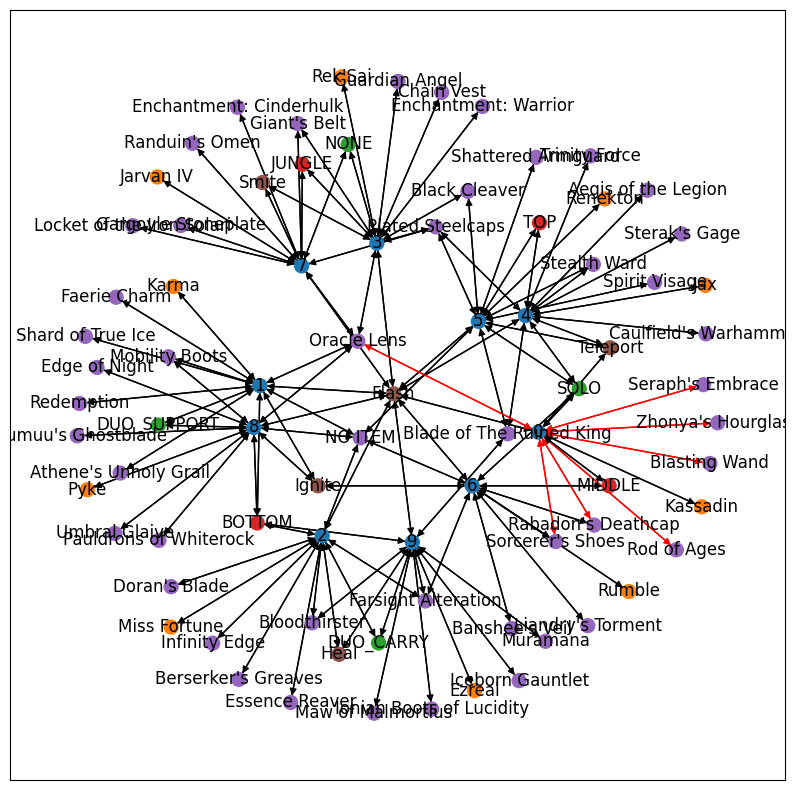

In [8]:
def get_matches(limit = None):
    matches_query = """MATCH (m:Match) 
        WHERE m.gameType = "MATCHED_GAME" AND m.gameMode = "CLASSIC" AND 
            apoc.date.parse(toString(m.gameDuration), 's', 'HH:mm:ssX') > 1800
        RETURN m"""
    
    if limit is not None:
        matches_query = matches_query + " LIMIT " + str(limit)
        
    return np.array([x["m"]["matchID"] for x in neo4j.exec(matches_query)[0]])

matches = get_matches(1000)
encoded_match = encode_match(matches[0])
plot_graph(encoded_match[0].numpy(), encoded_match[1].numpy())

In [9]:
matches_train, matches_test_validation = train_test_split(matches, train_size=0.8, random_state=random_state)
matches_test, matches_validation = train_test_split(matches_test_validation, train_size=0.5, random_state=random_state)

matches_train = [encode_match(match) for match in tqdm.tqdm(matches_train)]
matches_test = [encode_match(match) for match in tqdm.tqdm(matches_test)]
matches_validation = [encode_match(match) for match in tqdm.tqdm(matches_validation)]

print(f"Train: {len(matches_train)}, Test: {len(matches_test)}, Validation: {len(matches_validation)}")

100%|██████████| 100/100 [00:02<00:00, 38.12it/s]

Train: 800, Test: 100, Validation: 100


In [10]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.fc = torch.nn.Linear(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        # x = F.relu(x)
        x = self.fc(x).sum(dim=1)   
        return F.log_softmax(x, dim=0)

model = GCN(len(input_classes)+1, 1000, number_nodes)
model

GCN(
  (conv1): GCNConv(6, 1000)
  (conv2): GCNConv(1000, 1000)
  (fc): Linear(in_features=1000, out_features=764, bias=True)
)

In [11]:
if torch.cuda.is_available():
    nodes_matrix = nodes_matrix.cuda()
    model = model.cuda()

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
#optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

save_path = "models/"
train_losses = []
validation_losses = []

def train(epochs = 100, early_stopping_limit=10):
    best_model = None
    best_val_loss = np.inf
    early_stopping = 0
    
    for epoch in range(epochs):
        print(f"", end = "")
        if early_stopping == early_stopping_limit:
            print(f"Early stopping...")
            break
            
        model.train()
        train_loss = 0.0
        
        losses_epoch = []
        for i, (adj_matrix, result_vector, edge_index) in enumerate(matches_train):
            print(f"\rTraining epoch {epoch}: {float(i) / float(len(matches_train))}", end="")
            optimizer.zero_grad()
            
            if torch.cuda.is_available():
                edge_index, result_vector = edge_index.cuda(), result_vector.cuda()
            
            out = model(nodes_matrix, edge_index)
            
            loss = criterion(out, result_vector)
            losses_epoch.append(loss.item())
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        train_loss /= len(matches_train)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for i, (adj_matrix, result_vector, edge_index) in enumerate(matches_validation):
                print(f"\rValidating epoch {epoch}: {float(i) / float(len(matches_validation))}", end="")
                    
                if torch.cuda.is_available():
                    edge_index, result_vector = edge_index.cuda(), result_vector.cuda()
                
                out = model(nodes_matrix, edge_index)
                
                loss = criterion(out, result_vector)
                val_loss += loss.item() 
                
            val_loss /= len(matches_validation)
            validation_losses.append(val_loss)
        
        early_stopping += 1
            
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = f"model_items_{epoch}.pt"
            torch.save(model.state_dict(), save_path + best_model)
            early_stopping = 0
        
        print(f"Done: Training Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}")
        
    return best_model
    
model_file = train()

Validating epoch 0: 0.99Done: Training Loss: 192.5378, Validation Loss: 44.2021
Validating epoch 1: 0.99Done: Training Loss: 44.0132, Validation Loss: 44.2704
Validating epoch 2: 0.99Done: Training Loss: 44.0150, Validation Loss: 44.2414
Validating epoch 3: 0.99Done: Training Loss: 44.0429, Validation Loss: 44.2414
Validating epoch 4: 0.99Done: Training Loss: 44.0159, Validation Loss: 44.2304
Validating epoch 5: 0.99Done: Training Loss: 44.0180, Validation Loss: 44.2304
Validating epoch 6: 0.99Done: Training Loss: 44.0192, Validation Loss: 44.2412
Validating epoch 7: 0.99Done: Training Loss: 44.0234, Validation Loss: 44.2297
Validating epoch 8: 0.99Done: Training Loss: 44.0214, Validation Loss: 44.2541
Validating epoch 9: 0.99Done: Training Loss: 44.0341, Validation Loss: 44.2541
Validating epoch 10: 0.99Done: Training Loss: 972.0815, Validation Loss: 44.2458
Early stopping...


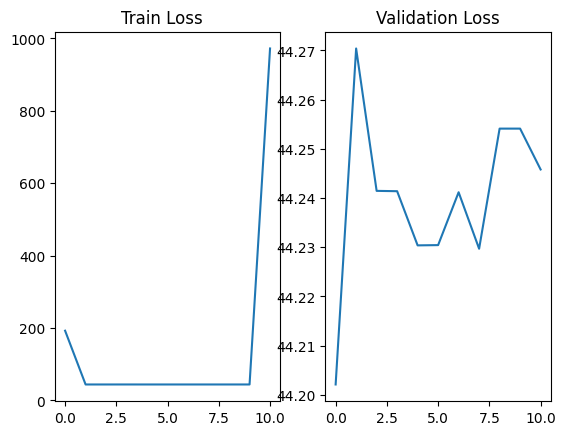

In [12]:
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(train_losses)
ax2.plot(validation_losses)
ax1.title.set_text('Train Loss  ')
ax2.title.set_text('Validation Loss')
plt.show()

In [13]:
model = GCN(len(input_classes)+1, 1000, number_nodes)
model.load_state_dict(torch.load(save_path + model_file))
if torch.cuda.is_available():
    model = model.cuda()

In [16]:
def evaluation():
    model.eval()
    ys,y_hats, hits, hit_rates = [], [], [], []
    for adj_matrix, result_vector, edge_index in matches_test:
        if torch.cuda.is_available():
            edge_index, result_vector = edge_index.cuda(), result_vector.cuda()
        
        y = [node_encodings_rev[x] for x in np.where(result_vector.cpu().detach().numpy()==1)[0]]
        ys.append(y)
        
        prediction = model(nodes_matrix, edge_index)
        y_hat = [node_encodings_rev[x] for x in prediction.squeeze().cpu().detach().numpy().argsort()[-10:]]
        y_hats.append(y_hat)
        
        hit = [item for item in y if item in y_hat]
        
        hits.append(hit)
        hit_rates.append(len(hit))
    return {"y": ys, "y_hat": y_hats, "hit": hits, "hit_rate": hit_rates}


eval_results = evaluation()
df_eval_results = pd.DataFrame(eval_results)
df_eval_results

,y,y_hat,hit,hit_rate
0,"[Item_Hextech Rocketbelt, Item_Fiendish Codex,...","[Item_Dark Seal, Item_Targon's Brace, Item_Ada...",[Item_Oracle Lens],1
1,"[Item_Runaan's Hurricane, Item_Farsight Altera...","[Item_Dark Seal, Item_Adaptive Helm, Item_Long...",[],0
2,"[Item_Haunting Guise, Item_Control Ward, Item_...","[Item_Adaptive Helm, Item_Cappa Juice, Item_Ki...",[],0
3,"[Item_Aegis of the Legion, Item_Bulwark of the...","[Item_Dark Seal, Item_Targon's Brace, Item_Ada...","[Item_Gargoyle Stoneplate, Item_Oracle Lens]",2
4,"[Item_Void Staff, Item_Luden's Echo, Item_Dark...","[Item_Targon's Brace, Item_Adaptive Helm, Item...",[Item_Oracle Lens],1
...,...,...,...,...
95,"[Item_Runaan's Hurricane, Item_Farsight Altera...","[Item_Adaptive Helm, Item_Cappa Juice, Item_Ki...",[],0
96,"[Item_Infernal Mask, Item_Forgefire Cape, Item...","[Item_Nashor's Tooth, Item_Dark Seal, Item_Ada...",[],0
97,"[Item_Luden's Echo, Item_Shard of True Ice, It...","[Item_Long Sword, Item_Cappa Juice, Item_Kindl...",[],0
98,"[Item_Wit's End, Item_Mobility Boots, Item_Con...","[Item_Long Sword, Item_Cappa Juice, Item_Kindl...",[Item_Oracle Lens],1


In [17]:
df_eval_results["hit_rate"].mean()

0.52